In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("car_price_dataset.csv", sep=";")

In [5]:

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Price"])  
# konverterar Price till nummer
# ogiltiga värden (text, saknade värden osv) blir NaN
# och tas sedan bort

In [6]:

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

df = df.dropna(subset=["Price", "Mileage", "Year"])


In [7]:
Most_expensive = df[df["Price"] == df["Price"].max()]   ## hittar den dyraste samt billigaste bilen
Least_expensive = df[df["Price"] == df["Price"].min()]
average_price = df["Price"].mean() ## genomsnitliga priset av alla bilar

In [8]:
most_miles = df[df["Mileage"] == df["Mileage"].max()] ## mest och minst miltal
least_miles = df[df["Mileage"] == df["Mileage"].min()]
average_miles = df["Mileage"].mean() ## genosnitlliga miltal

In [9]:
newest_car = df[df["Year"] == df["Year"].max()] ## nyaste och äldsta bilen
oldest_car = df[df["Year"] == df["Year"].min()]
average_age = df["Year"].mean() ## genomsnitts ålder på bilarna

In [10]:
cheap_cars = df[df["Price"] < average_price]  ## alla bilar som kostar mindre än genomsnittet räknas som billiga. 
expensive_cars = df[df["Price"] > average_price]## alla som kostar mer är dyra

In [11]:
high_mileage = df[df["Mileage"] > average_miles] ## högre samt lägre miltal än genomsnittet
low_mileage = df[df["Mileage"] < average_miles] 

In [12]:
old_cars = df[df["Year"] < average_age] ## kollar bilar äldre samt yngre än genomsnitt
new_cars = df[df["Year"] > average_age]

In [13]:
df["Score"] = 0 ## säger att alla bilar har 0 poäng innan deras egenskaper jämförs

In [14]:
## poängsystem där man kan jämföra för och nackdelar med bilarna
## en bil som är äldre än genomsnittet behöver inte vara en dålig bil 
## den kan ha bra egenskaper som att den är billig 
## eller har lågt miltal!
df.loc[df["Mileage"] < average_miles, "Score"] += 1 
df.loc[df["Mileage"] > average_miles, "Score"] -= 1  
df.loc[df["Year"] > average_age, "Score"] += 1
df.loc[df["Year"] < average_age, "Score"] -= 1
df.loc[df["Price"] < average_price, "Score"] += 1
df.loc[df["Price"] > average_price, "Score"] -= 1

In [15]:
too_good_to_be_true_cars = df[df["Score"] == 3]
Very_good_cars = df[df["Score"] >= 2]
good_cars = df[df["Score"] == 1]
neutral_cars = df[df["Score"] == 0]
bad_cars = df[df["Score"] == -1]
Very_bad_cars = df[df["Score"] == -2]
Horrible_cars = df[df["Score"] == -3]

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("car_price_dataset.csv", sep=";")

In [17]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

(array([ 239.,  251.,  386.,  487.,  645.,  751.,  838.,  983., 1011.,
         928.,  865.,  772.,  622.,  480.,  323.,  213.,  119.,   55.,
          22.,   10.]),
 array([ 2000.  ,  2815.05,  3630.1 ,  4445.15,  5260.2 ,  6075.25,
         6890.3 ,  7705.35,  8520.4 ,  9335.45, 10150.5 , 10965.55,
        11780.6 , 12595.65, 13410.7 , 14225.75, 15040.8 , 15855.85,
        16670.9 , 17485.95, 18301.  ]),
 <BarContainer object of 20 artists>)

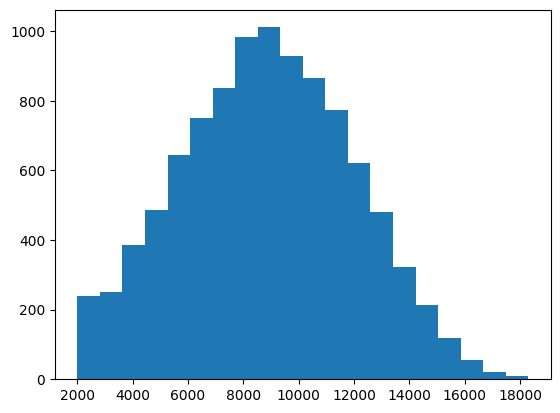

In [18]:
plt.hist(df["Price"], bins=20)

Text(0.5, 1.0, 'price distribution of cars')

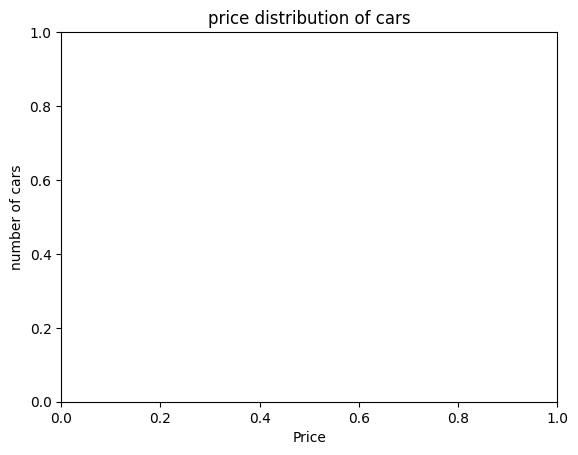

In [19]:
plt.xlabel("Price")
plt.ylabel("number of cars")
plt.title("price distribution of cars")

In [ ]:
plt.tight_layout()

In [ ]:
plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")


In [ ]:
plt.show()


In [ ]:
plt.scatter(df["Mileage"], df["Price"])


In [ ]:
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")

In [22]:
# sparar bilden
plt.savefig("price_vs_mileage.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [21]:
brand_avg = df.groupby("Brand")["Price"].mean().sort_values(ascending=False).head(10)


In [20]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

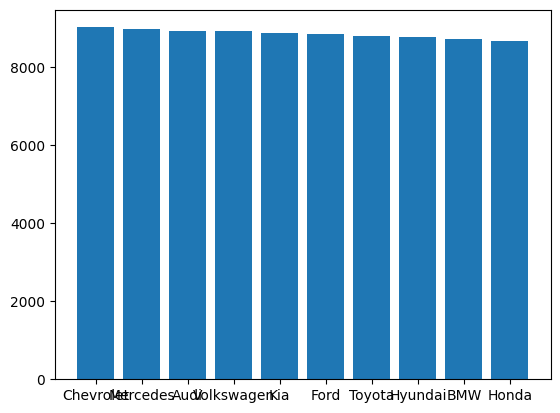

In [23]:
bars = plt.bar(brand_avg.index, brand_avg.values)

Text(0.5, 1.0, 'Top 10 Brands by Average Price')

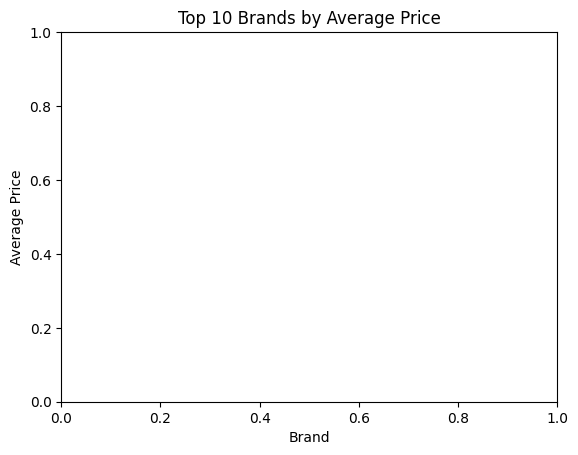

In [27]:
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.title("Top 10 Brands by Average Price")

In [ ]:
plt.xticks(rotation=45)

In [26]:
# visar värden
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha="center",
        va="bottom"
    )


MemoryError: bad allocation

<Figure size 640x480 with 1 Axes>

In [25]:
plt.savefig("Top_10_average", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [24]:
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>